# NPU/GPU MatMul Profiling

In [34]:
npu_result_path = "./mm_npu.csv"
gpu_result_path = "./mm_gpu.csv"

# result: {(M, N, K): (AI, compile time, runtime, throughput (TOPS), Power (mW))}
def parse_result(result_path):
    results = {}
    with open(result_path, "r") as f:
        next(f) 
        for line in f:
            items = [item.strip() for item in line.split(",")]
            assert len(items) == 11
            shape_key = (int(items[0]), int(items[1]), int(items[2]))
            if result_path == npu_result_path:
                results[shape_key] = (float(items[3]), int(items[5]), int(items[7]), float(items[9]), int(items[10]))
            else:
                results[shape_key] = (float(items[3]), int(items[4]), int(items[6]), float(items[8]), int(items[10]))
    return results

npu_results = parse_result(npu_result_path)
gpu_results = parse_result(gpu_result_path)

# (k, 4096, 4096)
keys = [(1, 4096, 4096)] + [(2**i, 4096, 4096) for i in range(4, 12)]
npu_data = [npu_results[key] for key in keys]
gpu_data = [gpu_results[key] for key in keys]


## Compile time
### [k, 4096] * [4096, 4096] and [4096, 4096] * [4096, k]

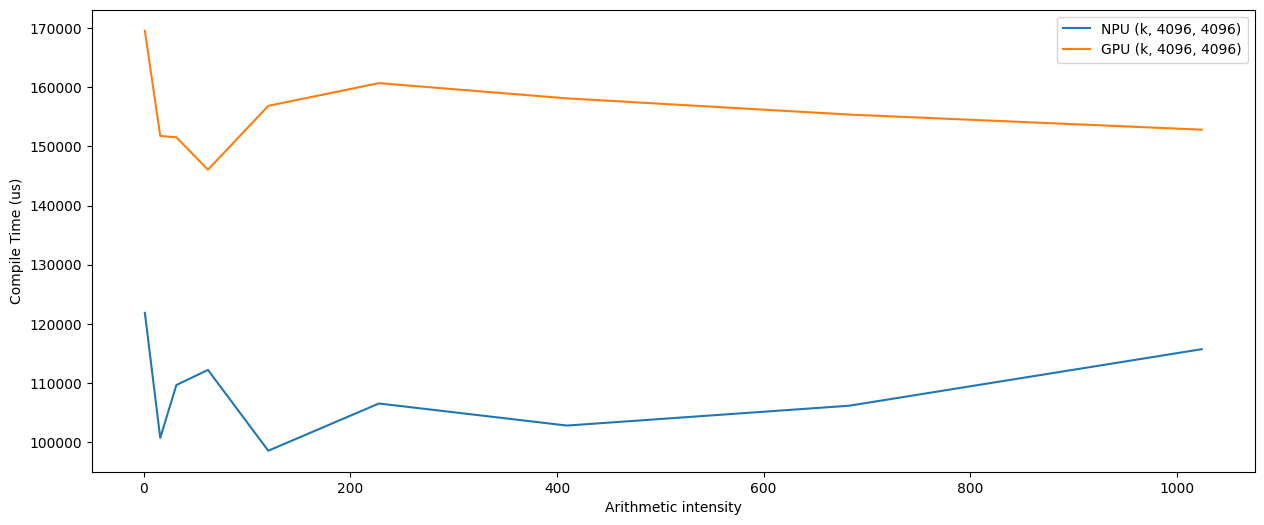

In [35]:
import matplotlib.pyplot as plt
import numpy as np    

x = [d[0] for d in npu_data]
npu_y = [d[1] for d in npu_data]
gpu_y = [d[1] for d in gpu_data]

# plot a line chart with common x and four lines with each y data
fig, ax = plt.subplots(figsize=(15, 6), dpi=100)
ax.plot(x, npu_y, label='NPU (k, 4096, 4096)')
ax.plot(x, gpu_y, label='GPU (k, 4096, 4096)')

ax.set_xlabel('Arithmetic intensity')
ax.set_ylabel('Compile Time (us)')
ax.legend()
plt.show()

## Runtime
### [k, 4096] * [4096, 4096] and [4096, 4096] * [4096, k]

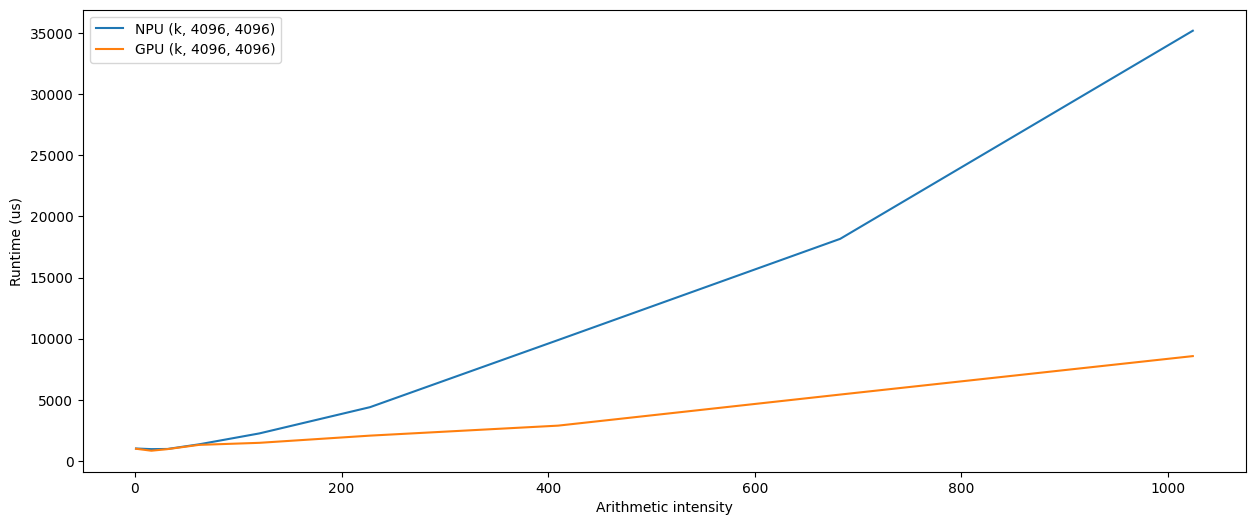

In [36]:
npu_y = [d[2] for d in npu_data]
gpu_y = [d[2] for d in gpu_data]

# plot a line chart with common x and four lines with each y data
fig, ax = plt.subplots(figsize=(15, 6), dpi=100)
ax.plot(x, npu_y, label='NPU (k, 4096, 4096)')
ax.plot(x, gpu_y, label='GPU (k, 4096, 4096)')
ax.set_xlabel('Arithmetic intensity')
ax.set_ylabel('Runtime (us)')
ax.legend()
plt.show()

## Throughput (TOPS)
### [k, 4096] * [4096, 4096] and [4096, 4096] * [4096, k]

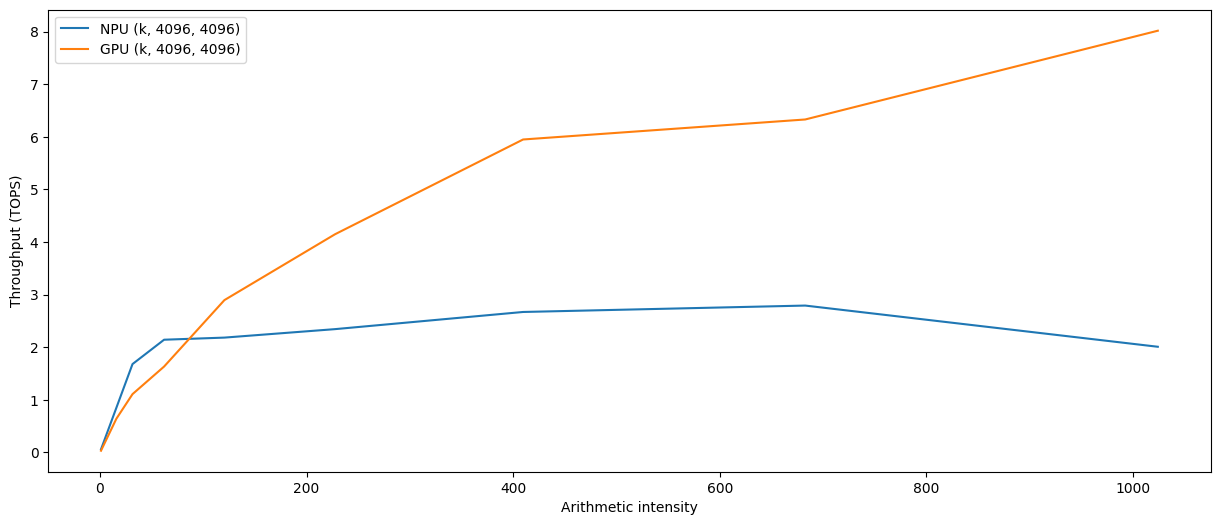

In [37]:
npu_y = [d[3] for d in npu_data]
gpu_y = [d[3] for d in gpu_data]

fig, ax = plt.subplots(figsize=(15, 6), dpi=100)
ax.plot(x, npu_y, label='NPU (k, 4096, 4096)')
ax.plot(x, gpu_y, label='GPU (k, 4096, 4096)')

ax.set_xlabel('Arithmetic intensity')
ax.set_ylabel('Throughput (TOPS)')
ax.legend()
plt.show()

## Power (mW)
### [k, 4096] * [4096, 4096] and [4096, 4096] * [4096, k]

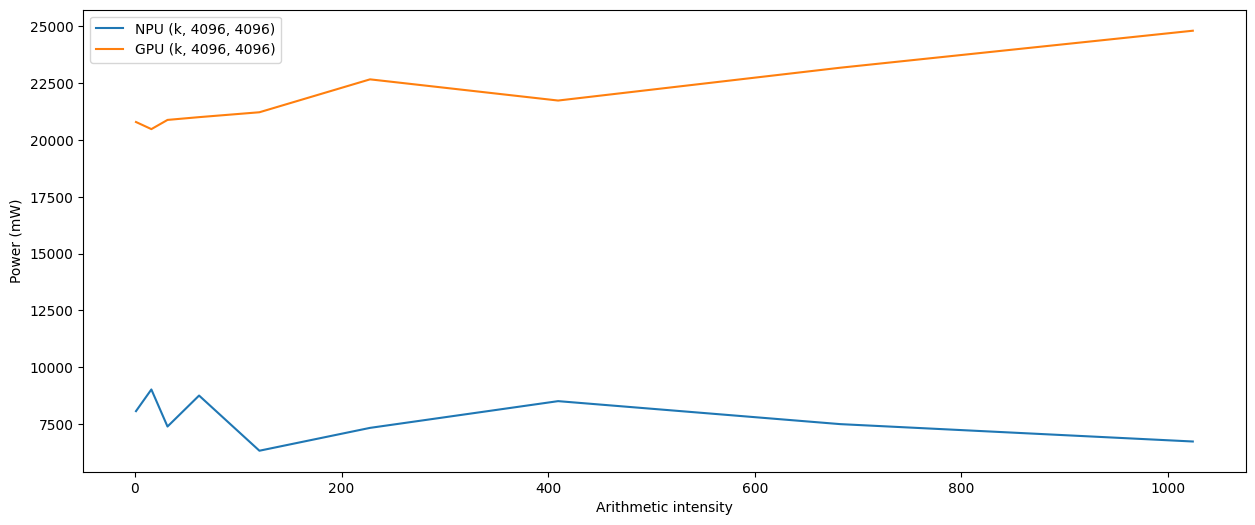

In [38]:
npu_y = [d[4] for d in npu_data]
gpu_y = [d[4] for d in gpu_data]

fig, ax = plt.subplots(figsize=(15, 6), dpi=100)
ax.plot(x, npu_y, label='NPU (k, 4096, 4096)')
ax.plot(x, gpu_y, label='GPU (k, 4096, 4096)')

ax.set_xlabel('Arithmetic intensity')
ax.set_ylabel('Power (mW)')
ax.legend()
plt.show()

## Energy Efficiency (TOPS/W)
### [k, 4096] * [4096, 4096] and [4096, 4096] * [4096, k]

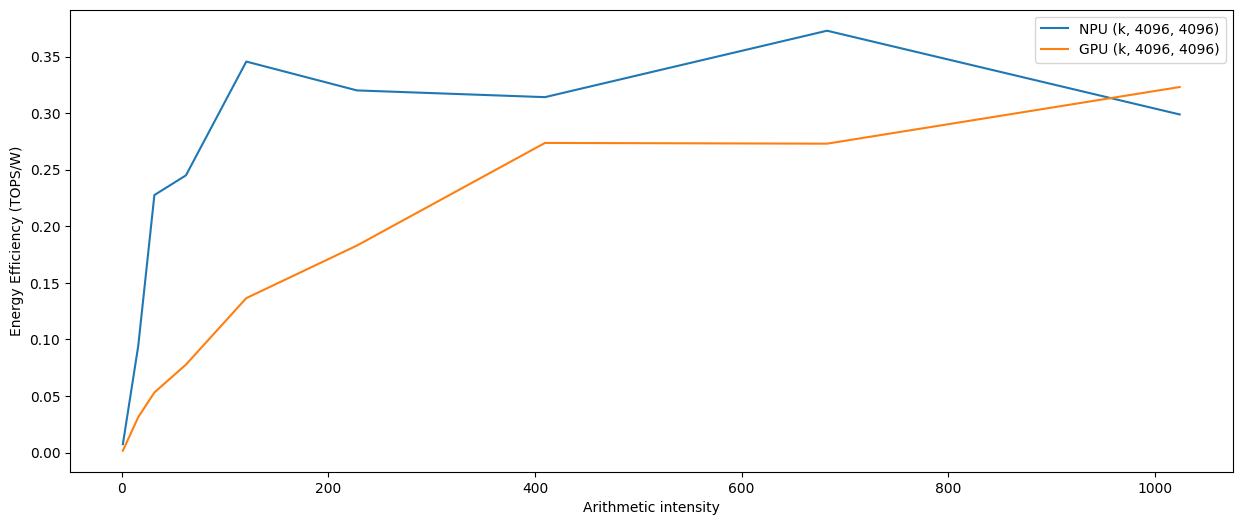

In [39]:
npu_p = [d[4] for d in npu_data]
gpu_p = [d[4] for d in gpu_data]

npu_y = [d[3] / d[4] * 1000 for d in npu_data]
gpu_y = [d[3] / d[4] * 1000 for d in gpu_data]

fig, ax = plt.subplots(figsize=(15, 6), dpi=100)
ax.plot(x, npu_y, label='NPU (k, 4096, 4096)')
ax.plot(x, gpu_y, label='GPU (k, 4096, 4096)')

ax.set_xlabel('Arithmetic intensity')
ax.set_ylabel('Energy Efficiency (TOPS/W)')
ax.legend()
plt.show()